<a href="https://colab.research.google.com/github/JoshuaCora1806/mi-lab-06-cs/blob/develop/Lab06_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

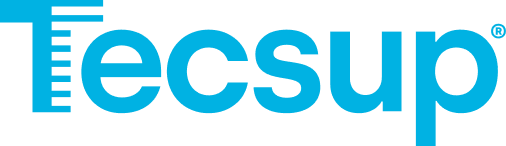

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 6
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

Indicaciones:
- El trabajo en su totalidad debe ser hecho en un notebook de ‘Jupyter’.
- Cree una cabecera que lleve por título el tema de la semana y debajo de él coloque un ‘Markdown’ con su nombre y apellido.
- Ejecute su notebook, grábelo, descárguelo como HTML, conviértalo a PDF y suba ambos archivos en el apartado que el docente indique.

## Actividad A
Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [200]:
# Importamos la libreria pandas para trabajar con dataframes
import pandas as pd

# Cargamos el archivo csv desde el repositorio
# Definimos la URL donde se encuentra el repositorio
url = 'https://archive.ics.uci.edu/static/public/15/data.csv'

# Usamos read_csv de pandas para leer la base de datos
df = pd.read_csv(url)

# Usamos head para ver los 5 primeros registros
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


Verificaremos el tipo de dato de cada varible

In [201]:
# Usamos info para saber más sobre el dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


Eliminaremos la variable "Sample_code_number" debido a que este es solo el ID del registro

In [202]:
# Usamos el comando drop para eliminar Sample_code_number
df=df.drop("Sample_code_number",axis=1)

In [203]:
# Verificamos la eliminación de Sample_code_number
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


Revisaremos si existen datos nulos en el dataframe.

In [204]:
# Importamos la libreria pandas
import pandas as pd

In [205]:
# Verificamos los nulos de cada variable
df.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


Existen nulos en la variable "Bare_nuclei" así que ahora revisaremos el porcentaje que representa esa cantidad respeto al total de datos.

In [206]:
# Obtenemos el porcentaje de nulos de Bare_nuclei
Bn_null = round((df["Bare_nuclei"].isnull().sum() / len(df)) * 100,2)
print(f"El porcentaje de nulos de Bare_nuclei es: {Bn_null}%")

El porcentaje de nulos de Bare_nuclei es: 2.29%


Al no representar un porcentaje tan alto, imputamos por la mediana de la variable.

In [207]:
# Imputamos los valores faltantes de Bare_nuclei con la mediana
df["Bare_nuclei"] = df["Bare_nuclei"].fillna(df["Bare_nuclei"].median())

In [208]:
# Revisamos los nulos de las variables para corroborar
df.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,0
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


La variable "Class" es la variable objetivo, indagando en el repositorio, podemos obserar que esta variable posee los valores 2 y 4, los cuales represantan SI o NO frente a la pregunta si el tumor es benigno (2=benigno, 4=maligno), así que intercambiaremos esos valores por 1 y 0.

In [209]:
# cambiar las categorías para la variable ‘Class’ de 2 y 4 por 1 y 0
df['Class'] = df['Class'].replace({2: 1, 4: 0})

# Verificar resultados
print("Valores de 'Class':", df['Class'].unique())

Valores de 'Class': [1 0]


Separamos la variable de clasificación del resto de avriables y obtenemos los datos de entrenamiento y prueba (25%)

In [210]:
from sklearn.model_selection import train_test_split # Para separar los dato de entrenamiento y prueba

In [211]:
# Separamos las variables predictoras (features) de la variable objetivo
X = df.drop("Class", axis=1)
y = df["Class"]

In [212]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Actividad B
Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

In [213]:
from sklearn.neighbors import KNeighborsClassifier    # Importamos el clasificador k-NN
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report     # Importamos para medir la precisión del modelo

In [214]:
# Creamos e entrenamos el modelo k-NN (con k=5 vecinos)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Generamos pronósticos para entrenamiento y prueba
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Medimos la precisión en ambos conjuntos
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Mostramos los resultados
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_test_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_test_pred))
print(f'Precisión en entrenamiento: {train_acc:.3f}')
print(f'Precisión en prueba:       {test_acc:.3f}')

Matriz de Confusión:
 [[ 55   2]
 [  2 116]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        57
           1       0.98      0.98      0.98       118

    accuracy                           0.98       175
   macro avg       0.97      0.97      0.97       175
weighted avg       0.98      0.98      0.98       175

Precisión en entrenamiento: 0.971
Precisión en prueba:       0.977


### Matriz de Confusión:
La matriz de confusión muestra un excelente rendimiento del modelo. De los 57 casos benignos (clase 0), el modelo clasificó correctamente 55 como benignos (Verdaderos Negativos) y solo 2 como malignos (Falsos Positivos). De los 118 casos malignos (clase 1), el modelo clasificó correctamente 116 como malignos (Verdaderos Positivos) y solo 2 como benignos (Falsos Negativos). Esto indica una baja tasa de errores tanto en la identificación de casos benignos como malignos.

### Reporte de Clasificación:

El reporte de clasificación confirma el alto rendimiento del modelo. La precisión para la clase 0 (benigno) es del 96%, lo que significa que el 96% de las veces que el modelo predijo benigno, fue correcto. La precisión para la clase 1 (maligno) es aún mayor, con un 98%. El recall (sensibilidad) también es alto para ambas clases, con un 96% para la clase 0 y un 98% para la clase 1, lo que indica que el modelo es capaz de identificar la mayoría de los casos reales de cada clase. El F1-score, que combina precisión y recall, es igualmente alto para ambas clases, confirmando un buen equilibrio entre ambas métricas. La precisión general (accuracy) del modelo es del 98%, lo que significa que predijo correctamente el 98% de todos los casos en el conjunto de prueba.

### Precisión en Entrenamiento y Prueba:
La precisión en el entrenamiento es del 97.1%, mientras que la precisión en la prueba es ligeramente superior, con un 97.7%. Esto indica que el modelo no está sobreajustado a los datos de entrenamiento y generaliza bien a nuevos datos. La ligera diferencia entre la precisión en el entrenamiento y la prueba es normal y aceptable, y en este caso, incluso sugiere una buena capacidad de generalización del modelo. Estos resultados son muy prometedores y demuestran la eficacia del modelo k-NN para este problema de clasificación.

## Actividad C
Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.

In [215]:
from imblearn.over_sampling import SMOTE # Para usar SMOTE

In [216]:
# Aplicamos SMOTE para balancear las clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [217]:
# Creamos y entrenamos el modelo k-NN con los datos balanceados
knn_balanced = KNeighborsClassifier(n_neighbors=5)
knn_balanced.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [218]:
# Generamos pronósticos para entrenamiento y prueba con el modelo balanceado
y_train_pred_balanced = knn_balanced.predict(X_train_resampled)  # Usa X_train_resampled
y_test_pred_balanced = knn_balanced.predict(X_test)

In [219]:
# Medimos la precisión en ambos conjuntos
train_acc_balanced = accuracy_score(y_train_resampled, y_train_pred_balanced)
test_acc_balanced = accuracy_score(y_test, y_test_pred_balanced)

# Mostramos los resultados para el modelo balanceado
print("Matriz de Confusión (Balanceado):\n", confusion_matrix(y_test, y_test_pred_balanced))
print("Reporte de clasificación (Balanceado):\n", classification_report(y_test, y_test_pred_balanced))
print(f'Precisión en entrenamiento (Balanceado): {train_acc_balanced:.3f}')
print(f'Precisión en prueba (Balanceado):       {test_acc_balanced:.3f}')

Matriz de Confusión (Balanceado):
 [[ 57   0]
 [  2 116]]
Reporte de clasificación (Balanceado):
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        57
           1       1.00      0.98      0.99       118

    accuracy                           0.99       175
   macro avg       0.98      0.99      0.99       175
weighted avg       0.99      0.99      0.99       175

Precisión en entrenamiento (Balanceado): 0.981
Precisión en prueba (Balanceado):       0.989


### COMPARACIÓN

#### Matriz de Confusion:
En la comparación de las matrices de confusión, ambos modelos muestran un desempeño excelente, pero el modelo balanceado reduce aún más los errores. En el primer modelo se observa que hubo 2 falsos negativos y 2 falsos positivos (55 verdaderos negativos y 116 verdaderos positivos), mientras que en el segundo modelo balanceado solo aparecen 2 falsos negativos y ningún falso positivo (57 verdaderos negativos y 116 verdaderos positivos). Esto implica que, al equilibrar las clases, se consiguió eliminar completamente los falsos positivos, mejorando la capacidad del modelo para no clasificar erróneamente casos negativos como positivos.

#### Reporte de Métricas:
Al analizar el reporte de métricas, el primer modelo obtiene una precisión y un recall de 0.96 para la clase 0 y de 0.98 para la clase 1, con un f1-score global de 0.97 (macro avg) y 0.98 (weighted avg). En contraste, el modelo balanceado logra elevar estas cifras a 0.97 de precisión y 1.00 de recall para la clase 0, y a 1.00 de precisión y 0.98 de recall para la clase 1, alcanzando un f1-score de 0.98 (clase 0), 0.99 (clase 1) y promedios de 0.99 (macro y weighted). Esto refleja una mejora especialmente notable en la sensibilidad sobre la clase minoritaria, traduciéndose en un f1-score más alto y un balance más uniforme entre precisión y recall.

#### Precisión en Entrenamiento y Prueba:
Finalmente, en cuanto a la precisión en entrenamiento y prueba, el primer modelo reporta 0.971 en entrenamiento y 0.977 en prueba. El modelo balanceado, por su parte, alcanza 0.981 en entrenamiento y 0.989 en prueba, lo que indica no solo un mayor ajuste a los datos de entrenamiento sino también una mejor generalización a datos no vistos. Este incremento en ambas fases sugiere que el balanceo de clases ha contribuido a un aprendizaje más robusto y estable, reduciendo tanto el sobreajuste como los errores de clasificación en conjunto.